<a href="https://colab.research.google.com/github/bhargavi-nakathe/leaf-disease-cv/blob/main/cnn_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inside a CNN — What happens to a leaf image?

This notebook shows exactly what happens to a real leaf image
at every layer of the CNN.

We will visualise:
1. The original image
2. After each Conv layer — what features were detected
3. After MaxPool — how the image shrinks
4. After Flatten — what the linear layer receives
5. The final 12 class scores

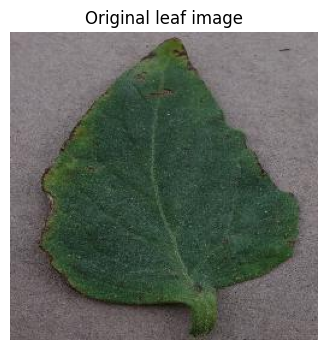

Original size: (256, 256)


In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms


# download a real tomato leaf image
img = Image.open("tomato.jpg").convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Original leaf image")
plt.axis("off")
plt.show()
print(f"Original size: {img.size}")  # (Width, Height)

## Step 1 — Transform the image

Before entering the CNN, the image must be:
- Resized to 224×224 (all images same size)
- Converted to tensor shape (3, 224, 224)
- Normalised to values ~-2 to +2

After this step: shape = (1, 3, 224, 224)
The extra 1 at the front = batch size of 1

After transform: torch.Size([1, 3, 224, 224])


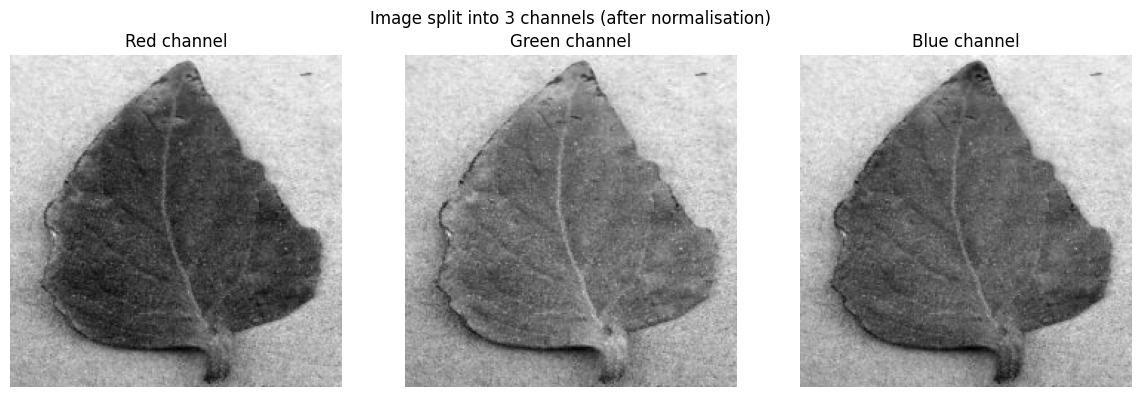

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# apply transform and add batch dimension
x = transform(img).unsqueeze(0)   # (3,224,224) → (1,3,224,224)
print(f"After transform: {x.shape}")

# show the 3 channels separately
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
channel_names = ["Red channel", "Green channel", "Blue channel"]
for i in range(3):
    axes[i].imshow(x[0][i].numpy(), cmap="gray")
    axes[i].set_title(channel_names[i])
    axes[i].axis("off")
plt.suptitle("Image split into 3 channels (after normalisation)")
plt.tight_layout()
plt.show()

## Step 2 — First Conv layer (3 → 32 channels)

The conv layer applies 32 different filters to the image.
Each filter slides across the image looking for a different pattern.

- Filter 1 might detect horizontal edges
- Filter 2 might detect dark spots
- Filter 3 might detect bright patches
...and so on for all 32 filters

Output shape: (1, 32, 224, 224)
Same spatial size because padding=1 preserves dimensions.

Input shape:        torch.Size([1, 3, 224, 224])
After Conv1 shape:  torch.Size([1, 32, 224, 224])


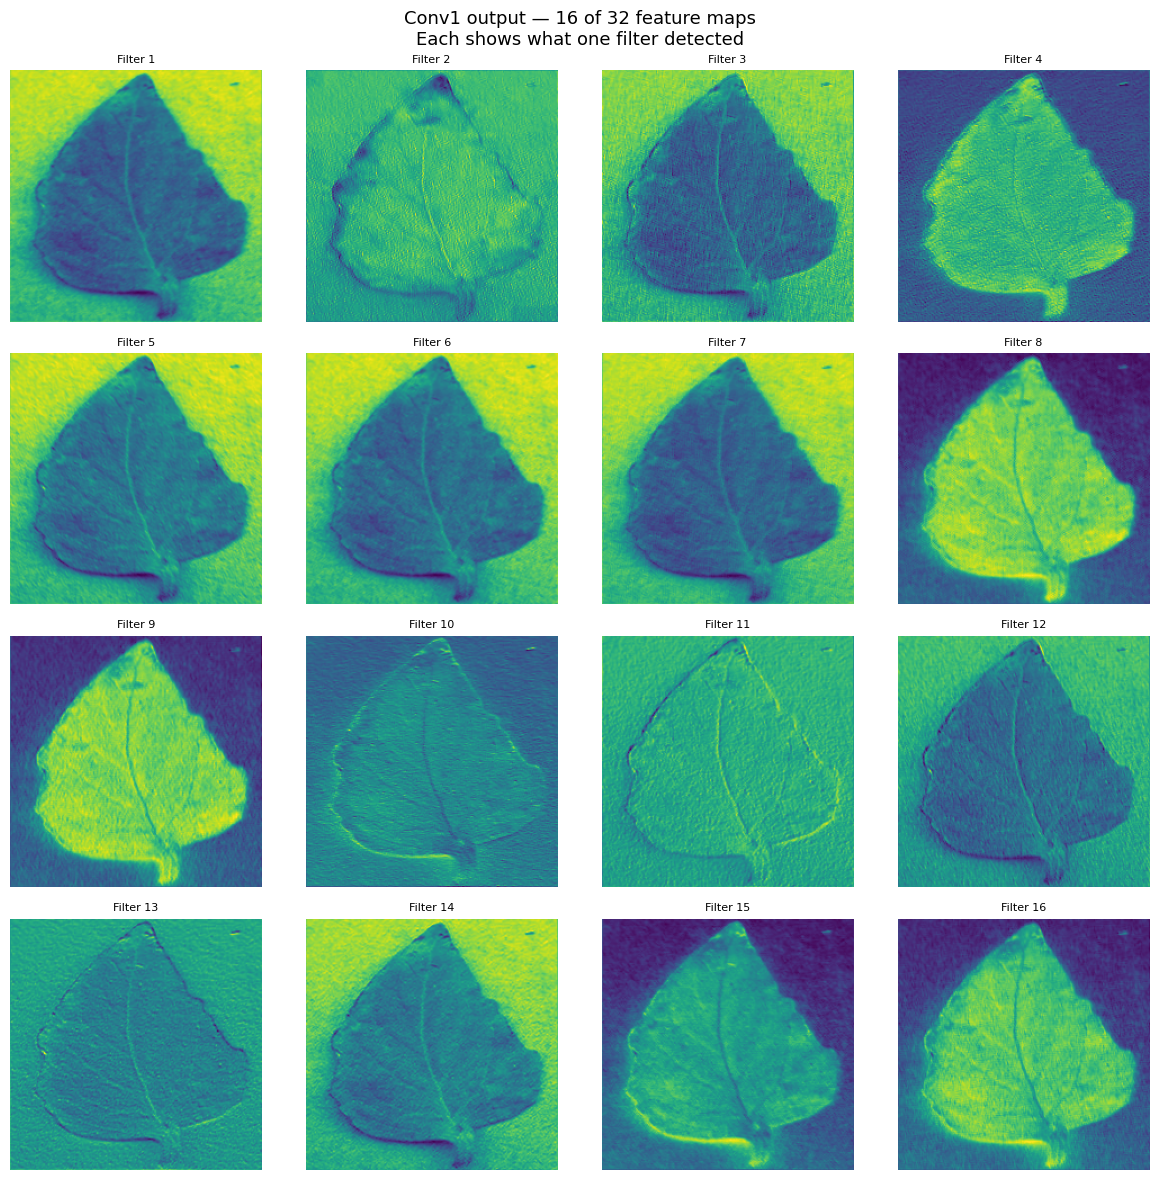

In [8]:
# define just the first conv layer
conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)

with torch.no_grad():
    out_conv1 = conv1(x)

print(f"Input shape:        {x.shape}")
print(f"After Conv1 shape:  {out_conv1.shape}")

# visualise first 16 of the 32 feature maps
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flatten()):
    feature_map = out_conv1[0][i].numpy()
    ax.imshow(feature_map, cmap="viridis")
    ax.set_title(f"Filter {i+1}", fontsize=8)
    ax.axis("off")
plt.suptitle("Conv1 output — 16 of 32 feature maps\nEach shows what one filter detected", fontsize=13)
plt.tight_layout()
plt.show()

## Step 3 — ReLU activation

ReLU sets all negative values to zero.
Why? Negative values mean "this pattern was NOT here".
We only care about where patterns WERE detected.

Before ReLU: values range from negative to positive
After ReLU:  all negative values become 0

Shape stays the same: (1, 32, 224, 224)

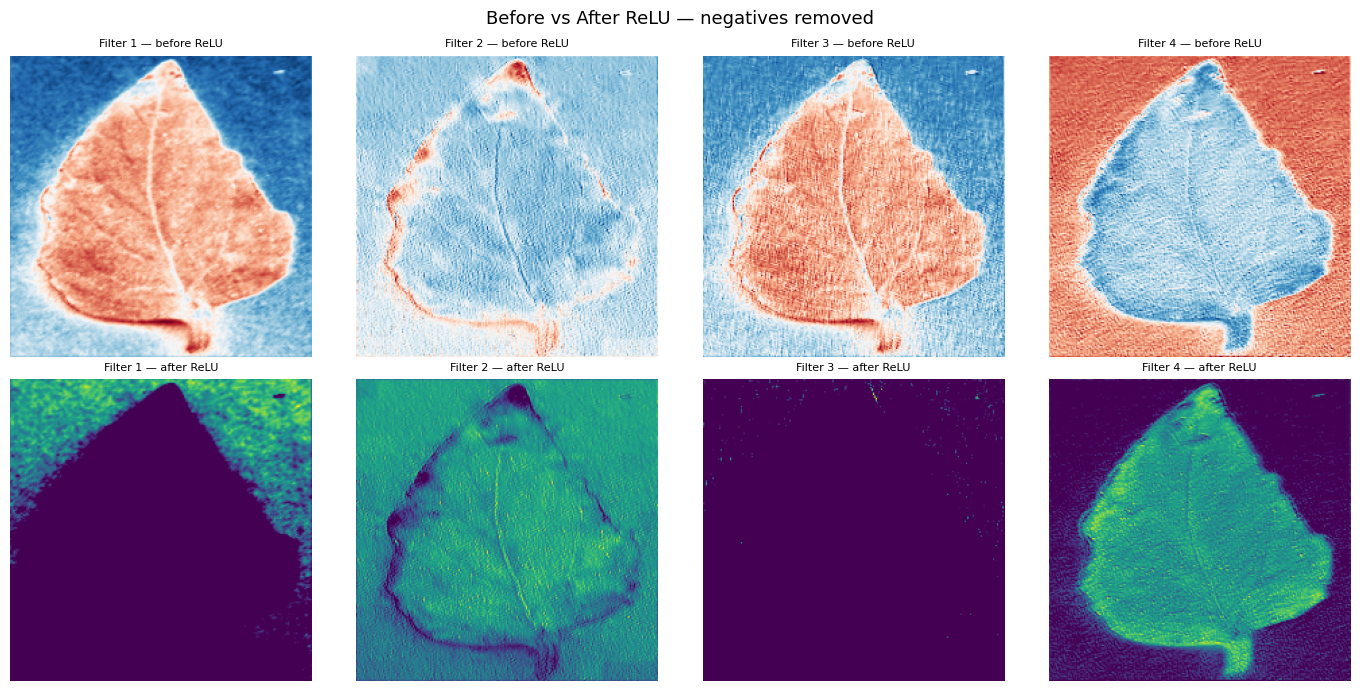

Min value before ReLU: -2.814
Min value after ReLU:  0.000  ← always 0


In [9]:
relu = nn.ReLU()
out_relu1 = relu(out_conv1)

# show same filter before and after ReLU
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i in range(4):
    # before ReLU
    axes[0][i].imshow(out_conv1[0][i].numpy(), cmap="RdBu")
    axes[0][i].set_title(f"Filter {i+1} — before ReLU", fontsize=8)
    axes[0][i].axis("off")

    # after ReLU
    axes[1][i].imshow(out_relu1[0][i].numpy(), cmap="viridis")
    axes[1][i].set_title(f"Filter {i+1} — after ReLU", fontsize=8)
    axes[1][i].axis("off")

plt.suptitle("Before vs After ReLU — negatives removed", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Min value before ReLU: {out_conv1.min().item():.3f}")
print(f"Min value after ReLU:  {out_relu1.min().item():.3f}  ← always 0")

## Step 4 — MaxPool2d (224 → 112)

MaxPool slides a 2×2 window across the feature map.
It keeps only the maximum value in each 2×2 block.

Why?
- Reduces computation (smaller feature map)
- Makes the model less sensitive to exact position
  (a spot detected at pixel 10 or pixel 11 gives same result)

Before MaxPool: (1, 32, 224, 224)
After MaxPool:  (1, 32, 112, 112)  ← halved

Before MaxPool: torch.Size([1, 32, 224, 224])
After MaxPool:  torch.Size([1, 32, 112, 112])


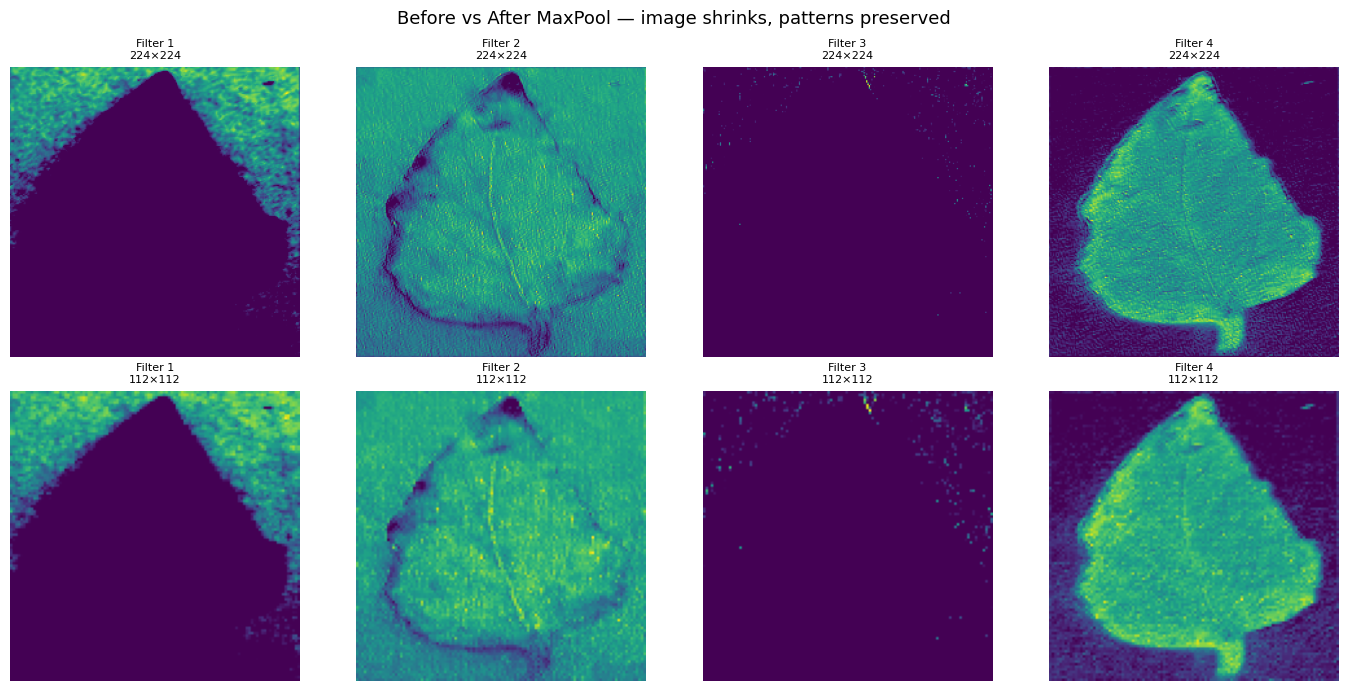

In [10]:
pool = nn.MaxPool2d(2, 2)
out_pool1 = pool(out_relu1)

print(f"Before MaxPool: {out_relu1.shape}")
print(f"After MaxPool:  {out_pool1.shape}")

# show same filter before and after pooling
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0][i].imshow(out_relu1[0][i].numpy(), cmap="viridis")
    axes[0][i].set_title(f"Filter {i+1}\n224×224", fontsize=8)
    axes[0][i].axis("off")

    axes[1][i].imshow(out_pool1[0][i].numpy(), cmap="viridis")
    axes[1][i].set_title(f"Filter {i+1}\n112×112", fontsize=8)
    axes[1][i].axis("off")

plt.suptitle("Before vs After MaxPool — image shrinks, patterns preserved", fontsize=13)
plt.tight_layout()
plt.show()

## Step 5 — Block 2 and Block 3

Same process repeats two more times.
Each block finds more complex patterns by combining
what the previous block detected.

Block 1 finds: edges, colour patches
Block 2 finds: combinations of edges → shapes, spots
Block 3 finds: combinations of shapes → disease patterns

Shape after Block 2: (1, 64,  56, 56)
Shape after Block 3: (1, 128, 28, 28)

After Block 1: torch.Size([1, 32, 112, 112])
After Block 2: torch.Size([1, 64, 56, 56])
After Block 3: torch.Size([1, 128, 28, 28])


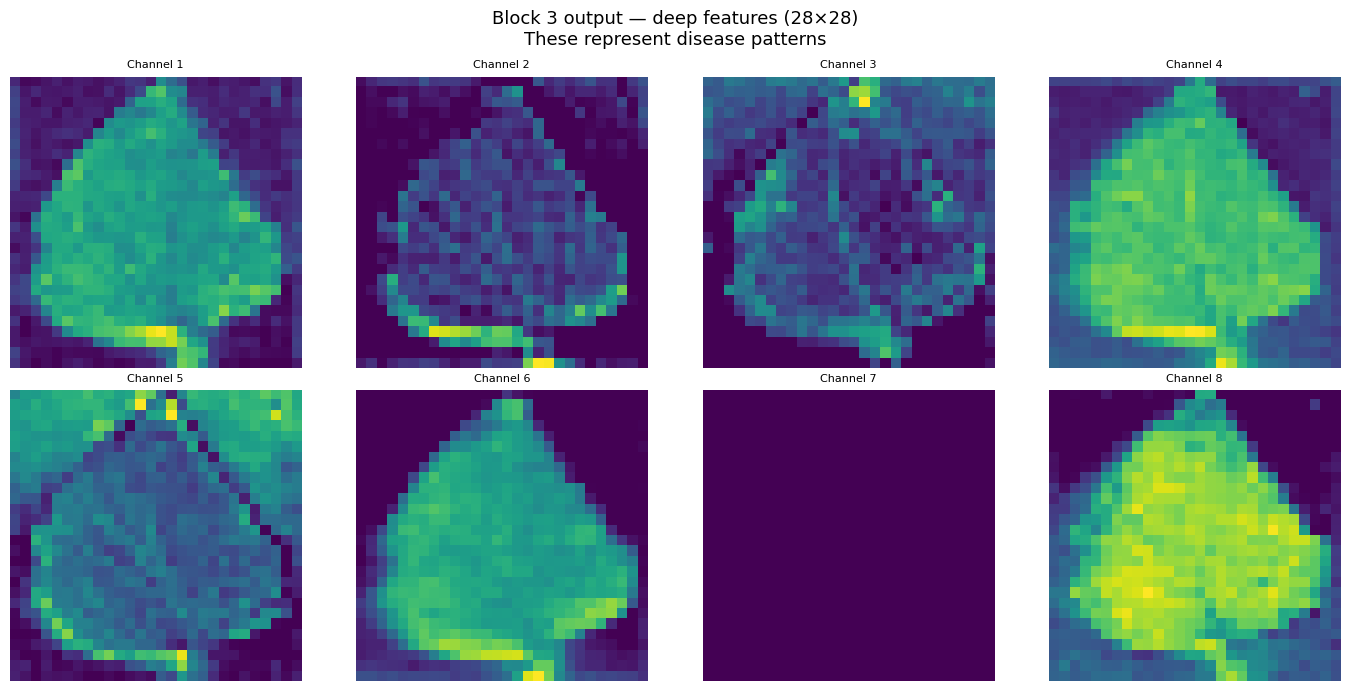

In [11]:
# block 2
conv2  = nn.Conv2d(32, 64,  kernel_size=3, padding=1)
conv3  = nn.Conv2d(64, 128, kernel_size=3, padding=1)

with torch.no_grad():
    # block 2
    out_b2 = pool(relu(conv2(out_pool1)))
    # block 3
    out_b3 = pool(relu(conv3(out_b2)))

print(f"After Block 1: {out_pool1.shape}")
print(f"After Block 2: {out_b2.shape}")
print(f"After Block 3: {out_b3.shape}")

# show 8 feature maps from block 3
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(out_b3[0][i].numpy(), cmap="viridis")
    ax.set_title(f"Channel {i+1}", fontsize=8)
    ax.axis("off")
plt.suptitle("Block 3 output — deep features (28×28)\nThese represent disease patterns", fontsize=13)
plt.tight_layout()
plt.show()

## Step 6 — AdaptiveAvgPool2d vs Flatten

Problem with plain Flatten:
  nn.Linear(128 * 28 * 28, 256) only works for 224×224 images.
  A 256×256 image → (128, 32, 32) → 131072 numbers → CRASH

AdaptiveAvgPool2d(1) fixes this:
  It averages each channel's entire feature map into one number.
  (1, 128, 28, 28) → (1, 128, 1, 1) → flatten → (1, 128)
  Always 128 numbers regardless of input size.

This is why modern CNNs use AdaptiveAvgPool2d instead of large Flatten.

Plain Flatten output:          torch.Size([1, 100352])
AdaptiveAvgPool + Flatten:     torch.Size([1, 128])


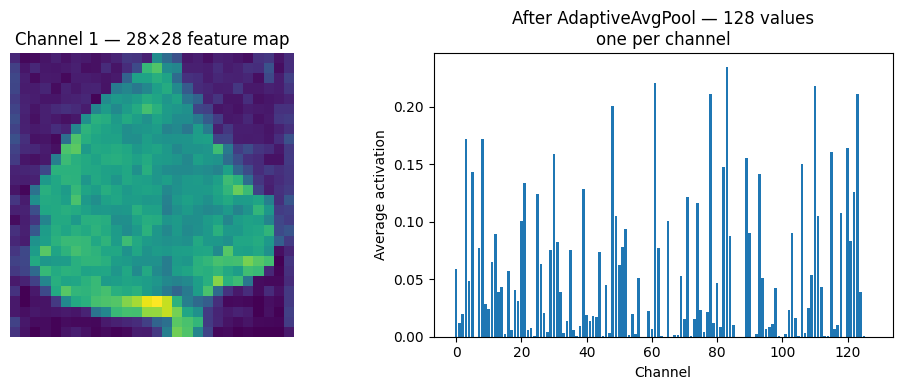

In [12]:
# compare both approaches
adaptive_pool = nn.AdaptiveAvgPool2d(1)
flatten       = nn.Flatten()

# approach 1 — plain flatten
out_flat = flatten(out_b3)
print(f"Plain Flatten output:          {out_flat.shape}")  # 100352

# approach 2 — adaptive pool then flatten
out_adaptive = flatten(adaptive_pool(out_b3))
print(f"AdaptiveAvgPool + Flatten:     {out_adaptive.shape}")  # 128

# show what adaptive pool does — averages each channel
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(out_b3[0][0].numpy(), cmap="viridis")
axes[0].set_title("Channel 1 — 28×28 feature map")
axes[0].axis("off")

axes[1].bar(range(128), out_adaptive[0].numpy())
axes[1].set_title("After AdaptiveAvgPool — 128 values\none per channel")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Average activation")
plt.tight_layout()
plt.show()

## Step 7 — Linear layers and final prediction

The 128 numbers from AdaptiveAvgPool represent the
entire image as a compact summary of its features.

Linear layers compress this further and output 12 scores.
The class with the highest score = predicted disease.

Note: weights are random here — model is not trained yet.
After training, these scores will be meaningful.

After Linear 1: torch.Size([1, 256])
After Linear 2: torch.Size([1, 12])


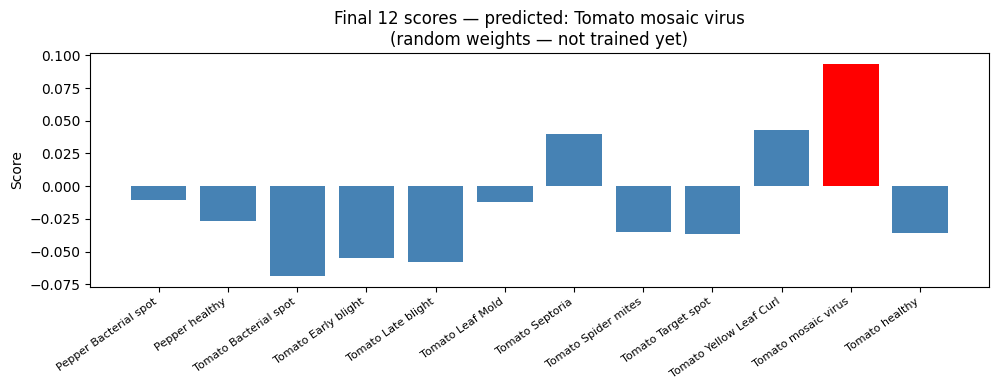

In [13]:
# linear layers
linear1 = nn.Linear(128, 256)
linear2 = nn.Linear(256, 12)

with torch.no_grad():
    out_l1 = relu(linear1(out_adaptive))
    out_l2 = linear2(out_l1)

print(f"After Linear 1: {out_l1.shape}")
print(f"After Linear 2: {out_l2.shape}")

# show final 12 scores
classes = [
    "Pepper Bacterial spot", "Pepper healthy",
    "Tomato Bacterial spot", "Tomato Early blight",
    "Tomato Late blight",    "Tomato Leaf Mold",
    "Tomato Septoria",       "Tomato Spider mites",
    "Tomato Target spot",    "Tomato Yellow Leaf Curl",
    "Tomato mosaic virus",   "Tomato healthy"
]

scores = out_l2[0].numpy()
predicted = scores.argmax()

plt.figure(figsize=(10, 4))
bars = plt.bar(range(12), scores, color=["red" if i == predicted else "steelblue" for i in range(12)])
plt.xticks(range(12), classes, rotation=35, ha="right", fontsize=8)
plt.title(f"Final 12 scores — predicted: {classes[predicted]}\n(random weights — not trained yet)")
plt.ylabel("Score")
plt.tight_layout()
plt.show()